In [1]:
import geopandas as gpd
import pandas as pd

In [2]:
!ls ../data

brussels_metro_lines.parquet	 Perimeter_Sc4_inhabitant.geojson
brussels_metro_stations.parquet  Sonian_forest_evac_area.geojson
Perimeter_Sc4_2areas.geojson	 Sonian_forest.geojson


In [3]:
flood_perimeter = gpd.read_file('../data/Perimeter_Sc4_2areas.geojson')
flood_inhabitants = gpd.read_file('../data/Perimeter_Sc4_inhabitant.geojson')

In [4]:
flood_perimeter

,fid,Zones,geometry
0,2,Scénario 4,"POLYGON ((4.33742 50.84849, 4.34266 50.83444, ..."
1,1,Scénario 4,"POLYGON ((4.34266 50.83444, 4.33742 50.84849, ..."


In [5]:
flood_inhabitants

,fid,Zones,communes,Habitants,Male,Female,Group0_14,Group_15_64,Group65+,geometry
0,17,Scénario 4,Forest_BXL-Ville_Saint-Josse-Anderlecht_Saint_...,103195,54029,49166,19792,73747,9656,"POLYGON ((4.353 50.87101, 4.35795 50.87363, 4...."


In [7]:
sonian_forest = gpd.read_file('../data/Sonian_forest.geojson')
sonian_evacuation_area = gpd.read_file('../data/Sonian_forest_evac_area.geojson')


In [ ]:
f = sonian_forest.geometry.values[0]
s = sonian_evacuation_area.geometry.values[0]

In [65]:
areas = [sonian_forest.geometry.values[0], sonian_evacuation_area.geometry.values[0]]
gpd.GeoDataFrame(geometry=areas, crs=sonian_evacuation_area.crs).explore()

In [66]:
sonian_forest.explore()

In [9]:
import numpy as np
from scipy.interpolate import make_interp_spline
from shapely.geometry import LineString, MultiPolygon, Polygon
from shapely.ops import split


def _extract_polygons(geom):
    if geom is None or geom.is_empty:
        return []
    if isinstance(geom, Polygon):
        return [geom]
    if hasattr(geom, "geoms"):
        out = []
        for g in geom.geoms:
            out.extend(_extract_polygons(g))
        return out
    return []


def _extend_chord(chord, eps):
    coords = np.array(chord.coords, dtype=float)
    if len(coords) < 2:
        return chord
    v_start = coords[0] - coords[1]
    norm_s = np.linalg.norm(v_start)
    if norm_s > 0:
        coords[0] = coords[0] + (v_start / norm_s) * eps
    v_end = coords[-1] - coords[-2]
    norm_e = np.linalg.norm(v_end)
    if norm_e > 0:
        coords[-1] = coords[-1] + (v_end / norm_e) * eps
    return LineString(coords)


def _split_with_single_chord(poly, line, eps):
    parts = _extract_polygons(split(poly, line))
    if len(parts) == 2:
        return parts
    # If a curvy line crosses a concave boundary multiple times, split along a single interior chord
    inter = poly.intersection(line)
    chords = [inter] if isinstance(inter, LineString) else list(getattr(inter, "geoms", []))
    chords = [c for c in chords if isinstance(c, LineString) and c.length > 0]
    best_two = None
    best_min_area = -1.0
    for c in chords:
        ext_c = _extend_chord(c, eps=eps)
        c_parts = _extract_polygons(split(poly, ext_c))
        if len(c_parts) == 2:
            m_area = min(c_parts[0].area, c_parts[1].area)
            if m_area > best_min_area:
                best_min_area = m_area
                best_two = c_parts
    return best_two if best_two is not None else parts


def _split_polygon_two(poly, target_ratio, rng):
    coords = np.array(poly.exterior.coords[:-1], dtype=float)
    center = coords.mean(axis=0)
    centered = coords - center
    if len(coords) >= 3:
        cov = np.cov(centered.T)
        _, eigvecs = np.linalg.eigh(cov)
        major_vec = eigvecs[:, 1]
        base_normal_angle = np.arctan2(major_vec[1], major_vec[0])
    else:
        base_normal_angle = rng.uniform(0, 2 * np.pi)

    total_area = poly.area
    target_area = target_ratio * total_area

    best_pair = None
    best_err = float("inf")

    for attempt in range(14):
        if attempt < 7:
            normal_angle = base_normal_angle + rng.uniform(-np.pi / 2.6, np.pi / 2.6)
        else:
            normal_angle = rng.uniform(0, 2 * np.pi)
        if rng.random() < 0.5:
            normal_angle += np.pi

        n = np.array([np.cos(normal_angle), np.sin(normal_angle)])
        u = np.array([-n[1], n[0]])

        proj_u = centered @ u
        proj_n = centered @ n
        u_min, u_max = proj_u.min(), proj_u.max()
        n_min, n_max = proj_n.min(), proj_n.max()
        span_u = u_max - u_min
        span_n = n_max - n_min
        if span_u <= 0 or span_n <= 0:
            continue

        eps = 1e-3 * min(span_u, span_n)
        s_start = u_min - 0.25 * span_u
        s_end = u_max + 0.25 * span_u
        n_ctrl = int(rng.integers(5, 9))
        ctrl_s = np.linspace(s_start, s_end, n_ctrl)

        # Smooth cubic spline wave for curvy internal edges; decay amplitude on late fallback attempts
        if attempt < 12:
            amp_scale = 0.15 * min(span_u, span_n) * (0.75 ** max(0, attempt - 4))
            raw_w = rng.uniform(-amp_scale, amp_scale, size=n_ctrl)
            raw_w -= raw_w.mean()
        else:
            raw_w = np.zeros(n_ctrl)

        s_dense = np.linspace(s_start, s_end, 64)
        spline = make_interp_spline(ctrl_s, raw_w, k=3)
        w_dense = spline(s_dense)

        lo = n_min - np.max(np.abs(w_dense))
        hi = n_max + np.max(np.abs(w_dense))

        for _ in range(13):
            mid = 0.5 * (lo + hi)
            pts = center + np.outer(s_dense, u) + np.outer(mid + w_dense, n)
            line = LineString(pts)
            parts = _split_with_single_chord(poly, line, eps)
            if len(parts) < 2:
                rp = np.array(poly.representative_point().coords[0]) - center
                s_rp = np.clip(rp @ u, s_start, s_end)
                if (rp @ n) < (mid + float(spline(s_rp))):
                    hi = mid
                else:
                    lo = mid
                continue

            rp0 = np.array(parts[0].representative_point().coords[0]) - center
            s_rp0 = np.clip(rp0 @ u, s_start, s_end)
            is_p0_neg = (rp0 @ n) < (mid + float(spline(s_rp0)))
            neg_part = parts[0] if is_p0_neg else parts[1]
            pos_part = parts[1] if is_p0_neg else parts[0]

            area_neg = neg_part.area
            err = abs(area_neg - target_area) / total_area

            if len(parts) == 2 and err < best_err:
                best_err = err
                best_pair = [neg_part, pos_part]

            if area_neg < target_area:
                lo = mid
            else:
                hi = mid

            if best_pair is not None and best_err < 0.015:
                return best_pair

        if best_pair is not None and best_err < 0.04:
            return best_pair

    return best_pair if best_pair is not None else [poly]


def _split_recursive(poly, n_pieces, rng):
    if n_pieces <= 1:
        return [poly]
    n1 = n_pieces // 2
    n2 = n_pieces - n1
    jitter = rng.uniform(-0.12, 0.12) / n_pieces if n_pieces > 2 else rng.uniform(-0.04, 0.04)
    target_ratio = float(np.clip((n1 / n_pieces) + jitter, 0.05, 0.95))
    pair = _split_polygon_two(poly, target_ratio, rng)
    if pair is None or len(pair) < 2:
        return [poly]
    return _split_recursive(pair[0], n1, rng) + _split_recursive(pair[1], n2, rng)


def random_split_geometry(polygon, size_ratio):
    """
    Randomly split a Shapely polygon into smaller sub-polygons with curvy internal edges
    that exactly partition the input polygon.

    Parameters
    ----------
    polygon : shapely.geometry.Polygon or MultiPolygon
        The input polygon geometry to split.
    size_ratio : float
        Relative target size of sub-polygons, strictly between 0 and 1 (0 < size_ratio < 1).
        - If size_ratio > 0.5: always returns 2 polygons of relative areas ~size_ratio and ~(1 - size_ratio).
        - If size_ratio <= 0.5: returns ~round(1 / size_ratio) polygons with average area ~size_ratio * polygon.area.

    Returns
    -------
    list[shapely.geometry.Polygon]
        List of sub-polygons whose union exactly covers the original polygon.
    """
    if not (0 < size_ratio < 1):
        raise ValueError("size_ratio must be strictly between 0 and 1 (0 < size_ratio < 1).")

    polys = _extract_polygons(polygon)
    if not polys:
        return []

    rng = np.random.default_rng()

    if len(polys) == 1:
        poly = polys[0]
        if size_ratio > 0.5:
            return _split_polygon_two(poly, size_ratio, rng)
        n_pieces = max(2, int(round(1.0 / size_ratio)))
        return _split_recursive(poly, n_pieces, rng)

    # MultiPolygon with multiple disconnected components
    total_area = sum(p.area for p in polys)
    if size_ratio > 0.5:
        polys_sorted = sorted(polys, key=lambda p: p.area, reverse=True)
        return _split_polygon_two(polys_sorted[0], size_ratio, rng) + polys_sorted[1:]

    n_total = max(len(polys), int(round(1.0 / size_ratio)))
    counts = [max(1, int(round(n_total * (p.area / total_area)))) for p in polys]
    result = []
    for p, k in zip(polys, counts):
        result.extend(_split_recursive(p, k, rng))
    return result

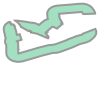

In [172]:
f = sh.GeometryCollection(sonian_forest.geometry.values)
s = sonian_evacuation_area.geometry.values[0].buffer(0.003)
se = gpd.read_file('geoman-geojson-2026-09-30_18-02-19.geojson').geometry.values[0]
sa = s.difference(f).difference(se)
sa

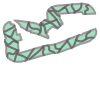

In [237]:
sub_polygons = random_split_geometry(sa, 0.03)
sh.GeometryCollection(sub_polygons)

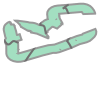

In [267]:
p1 = sh.unary_union(np.r_[sub_polygons][[16,17,18,19]])
p2 = sh.unary_union(np.r_[sub_polygons][[10,11,13,14,15]])
p3 = sh.unary_union(np.r_[sub_polygons][[1,2,3,4,5,12]])
p4 = sh.unary_union(np.r_[sub_polygons][[6,7,8,9]])
p5 = sh.unary_union(np.r_[sub_polygons][[20,21,22,24]])
p6 = sh.unary_union(np.r_[sub_polygons][[23,25,26,30,31,32]])
p7 = sh.unary_union(np.r_[sub_polygons][[27,28,29,33]])

source_areas = [p1,p2,p3,p4,p5,p6,p7]
sh.GeometryCollection(source_areas)

In [264]:
gpd.GeoDataFrame(geometry=source_areas, crs=sonian_evacuation_area.crs).explore()

In [259]:
source_areas = [{'shape': i, 'population': 10300, 'vehicle_occupancy': None} for i in source_areas]
import pickle
with open('brussels_fire_scenario.pkl', 'wb') as f:
    pickle.dump(source_areas, f)

In [266]:
with open('brussels_fire_scenario.pkl', 'rb') as f:
    z = pickle.load(f)

z

[{'shape': <POLYGON ((4.364 50.783, 4.364 50.784, 4.364 50.784, 4.364 50.784, 4.365 50....>,
  'population': 10300,
  'vehicle_occupancy': None},
 {'shape': <POLYGON ((4.395 50.755, 4.394 50.754, 4.394 50.754, 4.393 50.754, 4.391 50....>,
  'population': 10300,
  'vehicle_occupancy': None},
 {'shape': <POLYGON ((4.411 50.772, 4.413 50.772, 4.413 50.772, 4.415 50.773, 4.416 50....>,
  'population': 10300,
  'vehicle_occupancy': None},
 {'shape': <POLYGON ((4.491 50.786, 4.491 50.786, 4.49 50.786, 4.49 50.786, 4.49 50.785...>,
  'population': 10300,
  'vehicle_occupancy': None},
 {'shape': <POLYGON ((4.422 50.793, 4.422 50.793, 4.422 50.793, 4.422 50.793, 4.422 50....>,
  'population': 10300,
  'vehicle_occupancy': None},
 {'shape': <POLYGON ((4.416 50.808, 4.416 50.808, 4.416 50.808, 4.418 50.809, 4.418 50....>,
  'population': 10300,
  'vehicle_occupancy': None},
 {'shape': <POLYGON ((4.486 50.832, 4.486 50.832, 4.487 50.832, 4.489 50.83, 4.489 50.8...>,
  'population': 10300,
  'vehic

In [271]:
h = gpd.read_file('geoman-geojson-2026-09-30_18-47-45.geojson')
h.explore()

In [281]:
av = gpd.read_file('geoman-geojson-2026-09-30_18-52-29.geojson')
av.explore()

In [298]:
## source areas
sas = [{'name': f'area_{i:02d}', 
        'shape': geom, 
        'population': 1000 if i==2 else 5000 if i==3 else 12540 + np.random.randint(1000),
        'population-distribution': {'compliant': 70, 'self-directed': 20, 'disoriented': 10},
        'vehicle_occupancy': None} for i,geom in enumerate(source_areas)]

## target areas
tas = [{'name': 'heysel', 'shape': h.geometry.values[0], 'capacity': 100000, 'vehicle_occupancy': None}]

## red areas
ras = [{'name': 'sud-heysel', 'shape': av.geometry.values[0]}]


## vehicle locations
vh = [ 
    {'name': 'houtweg 99', 'lat': 50.87864299988982, 'lon': 4.410273724488832, 'count': 50, 'capacity_per_unit': 40, 'speed': 25, 'load_unload_secs_per_person': 10},
    {'name': 'biplan 75', 'lat': 50.88339923624641, 'lon': 4.410324380235859, 'count': 50, 'capacity_per_unit': 40, 'speed': 25, 'load_unload_secs_per_person': 10},
    {'name': 'industriel 14', 'lat': 50.82859625785035, 'lon': 4.317950608423478, 'count': 50, 'capacity_per_unit': 40, 'speed': 25, 'load_unload_secs_per_person': 10},
    {'name': 'vandermeeren 1', 'lat': 50.84707131348827, 'lon': 4.321116547230933, 'count': 50, 'capacity_per_unit': 40, 'speed': 25, 'load_unload_secs_per_person': 10},
    {'name': 'tyras 15', 'lat': 50.90848731036625, 'lon': 4.395375235430757, 'count': 50, 'capacity_per_unit': 40, 'speed': 25, 'load_unload_secs_per_person': 10},
]

scenario = { 'name': 'Bruxelles Forêt de Soignes',
             'source_areas': sas, 
             'target_areas': tas,
             'red_areas': ras,
             'vehicle_fleets': vh}

In [299]:
with open('../data/scenarios/bruxelles-scenario-soignes.pkl', 'wb') as f:
    pickle.dump(scenario, f)

In [300]:
with open('../data/scenarios/bruxelles-scenario-soignes.pkl', 'rb') as f:
    z = pickle.load(f)
scenario

{'name': 'Bruxelles Forêt de Soignes',
 'source_areas': [{'name': 'area_00',
   'shape': <POLYGON ((4.364 50.783, 4.364 50.784, 4.364 50.784, 4.364 50.784, 4.365 50....>,
   'population': 13441,
   'population-distribution': {'compliant': 70,
    'self-directed': 20,
    'disoriented': 10},
   'vehicle_occupancy': None},
  {'name': 'area_01',
   'shape': <POLYGON ((4.395 50.755, 4.394 50.754, 4.394 50.754, 4.393 50.754, 4.391 50....>,
   'population': 12829,
   'population-distribution': {'compliant': 70,
    'self-directed': 20,
    'disoriented': 10},
   'vehicle_occupancy': None},
  {'name': 'area_02',
   'shape': <POLYGON ((4.411 50.772, 4.413 50.772, 4.413 50.772, 4.415 50.773, 4.416 50....>,
   'population': 1000,
   'population-distribution': {'compliant': 70,
    'self-directed': 20,
    'disoriented': 10},
   'vehicle_occupancy': None},
  {'name': 'area_03',
   'shape': <POLYGON ((4.491 50.786, 4.491 50.786, 4.49 50.786, 4.49 50.786, 4.49 50.785...>,
   'population': 5000,
   